# Deep Learning Assignment - Transformer Approach
## Cashew Disease Indentification with AI (CADI-AI)

**Name** - Suhas Kanwar

**Class** - B.Tech-CSE-3

**Enrollment No.** - 230603

---

## Importing the libraries

In [ ]:
import os, yaml
import matplotlib.pyplot as plt
import torch
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from ultralytics import YOLO
import glob
import random
import torch
import torch.nn as nn
import torchvision.models as models
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Using device: cuda


## Loading the data

In [ ]:
print('\n--- Folder structure ---')
for root, dirs, fls in os.walk('/content/dataset'):
    depth = root.replace('/content/dataset', '').count(os.sep)
    indent = '  ' * depth
    print(f'{indent}{os.path.basename(root)}/')
    if depth < 3:
        for f in fls[:5]:
            print(f'{indent}  {f}')
        if len(fls) > 5:
            print(f'{indent}  ... ({len(fls)} files total)')

Dataset URL: https://www.kaggle.com/datasets/karaagroaiprojects/cadi-ai
License(s): GNU Affero General Public License 3.0
100% 3.52G/3.52G [01:38<00:00, 38.5MB/s]


--- Folder structure ---
dataset/
  Data/
    val/
      val/
        images/
        labels/
    train/
      train/
        images/
        labels/
    test/
      test/
        images/
        labels/


In [ ]:
def find_images_dir(base, split):
    for root, dirs, _ in os.walk(base):
        if os.path.basename(root) == 'images':
            if split in root:
                return root
    return None

base = '/content/dataset'
train_img = find_images_dir(base, 'train')
val_img = find_images_dir(base, 'valid') or find_images_dir(base, 'val')

train_lbl = train_img.replace('/images', '/labels') if train_img else None
val_lbl = val_img.replace('/images', '/labels') if val_img else None

print(f'Train images : {train_img}  ({len(os.listdir(train_img))} files)')
print(f'Train labels : {train_lbl}  ({len(os.listdir(train_lbl))} files)')
print(f'Val images   : {val_img}  ({len(os.listdir(val_img))} files)')
print(f'Val labels   : {val_lbl}  ({len(os.listdir(val_lbl))} files)')

data_yaml = {
    'train': train_img,
    'val': val_img,
    'nc': 3,
    'names': ['abiotic', 'insect', 'disease']
}

yaml_path = '/content/data.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f)

print(f'\ndata.yaml saved to {yaml_path}')
print(open(yaml_path).read())

Train images : /content/dataset/Data/train/train/images  (3788 files)
Train labels : /content/dataset/Data/train/train/labels  (3788 files)
Val images   : /content/dataset/Data/val/val/images  (710 files)
Val labels   : /content/dataset/Data/val/val/labels  (710 files)

data.yaml saved to /content/data.yaml
names:
- abiotic
- insect
- disease
nc: 3
train: /content/dataset/Data/train/train/images
val: /content/dataset/Data/val/val/images



## Baseline Model — YOLOv8s

Standard YOLOv8s trained with COCO-pretrained weights.

**Known limitations on CADI-AI (documented in original paper):**
- No spatial attention — model may focus on background foliage
- Disease/abiotic class confusion is high due to visual similarity

In [ ]:
baseline_detector = YOLO('yolov8s.pt')

run_metrics = baseline_detector.train(
    data=yaml_path,
    epochs=25,
    imgsz=640,
    batch=32,
    optimizer='AdamW',
    project='/kaggle/working/cadi_experiments',
    name='baseline_yolov8s',
    seed=42,
    exist_ok=True
)

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=baseline_yolov8s, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=100,

In [ ]:
validation_metrics = baseline_detector.val(data=yaml_path)

baseline_mAP50 = validation_metrics.box.map50
baseline_mAP50_95 = validation_metrics.box.map
baseline_precision = validation_metrics.box.mp
baseline_recall = validation_metrics.box.mr

baseline_f1 = 2 * (baseline_precision * baseline_recall) / (baseline_precision + baseline_recall + 1e-8)

print("\n" + "="*45)
print(" BASELINE MODEL (YOLOv8s) EVALUATION METRICS")
print("="*45)
print(f'Mean Average Precision (mAP@50) : {baseline_mAP50:.4f}')
print(f'mAP@50-95 (Strict IoU)          : {baseline_mAP50_95:.4f}')
print(f'Mean Precision                  : {baseline_precision:.4f}')
print(f'Mean Average Recall (mAR)       : {baseline_recall:.4f}')
print(f'Overall F1-Score                : {baseline_f1:.4f}')
print("="*45)

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3731.8±709.3 MB/s, size: 782.1 KB)
val: Scanning /content/dataset/Data/val/val/labels.cache... 710 images, 0 backgrounds, 1 corrupt: 100% ━━━━━━━━━━━━ 710/710 198.5Mit/s 0.0s
val: /content/dataset/Data/val/val/images/704.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0473]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 45/45 1.3it/s 35.9s
                   all        709       3224       0.44      0.382      0.355       0.13
               abiotic        154        254      0.477      0.508      0.476      0.178
                insect        409       1887      0.368      0.439      0.355      0.125
               disease        432       1083      0.475      0.199      0.23

In [ ]:
def calculate_f1_score(p, r):
    """Calculates the F1-score given precision and recall."""
    return 2 * p * r / (p + r + 1e-8)

baseline_f1 = calculate_f1_score(baseline_precision, baseline_recall)

print('YOLOv8s Baseline Results (Custom Run)')
print('-' * 40)
print(f'  mAP@50    : {baseline_mAP50:.4f}')
print(f'  mAP@50-95 : {baseline_mAP50_95:.4f}')
print(f'  Precision : {baseline_precision:.4f}')
print(f'  Recall    : {baseline_recall:.4f}')
print(f'  F1-Score  : {baseline_f1:.4f}')
print('-' * 40)

YOLOv8s Baseline Results (Custom Run)
----------------------------------------
  mAP@50    : 0.3551
  mAP@50-95 : 0.1299
  Precision : 0.4401
  Recall    : 0.3822
  F1-Score  : 0.4091
----------------------------------------



0: 544x640 1 abiotic, 2 diseases, 13.3ms
1: 544x640 (no detections), 13.3ms
2: 544x640 1 insect, 13.3ms
3: 544x640 3 insects, 13.3ms
Speed: 3.9ms preprocess, 13.3ms inference, 2.2ms postprocess per image at shape (1, 3, 544, 640)


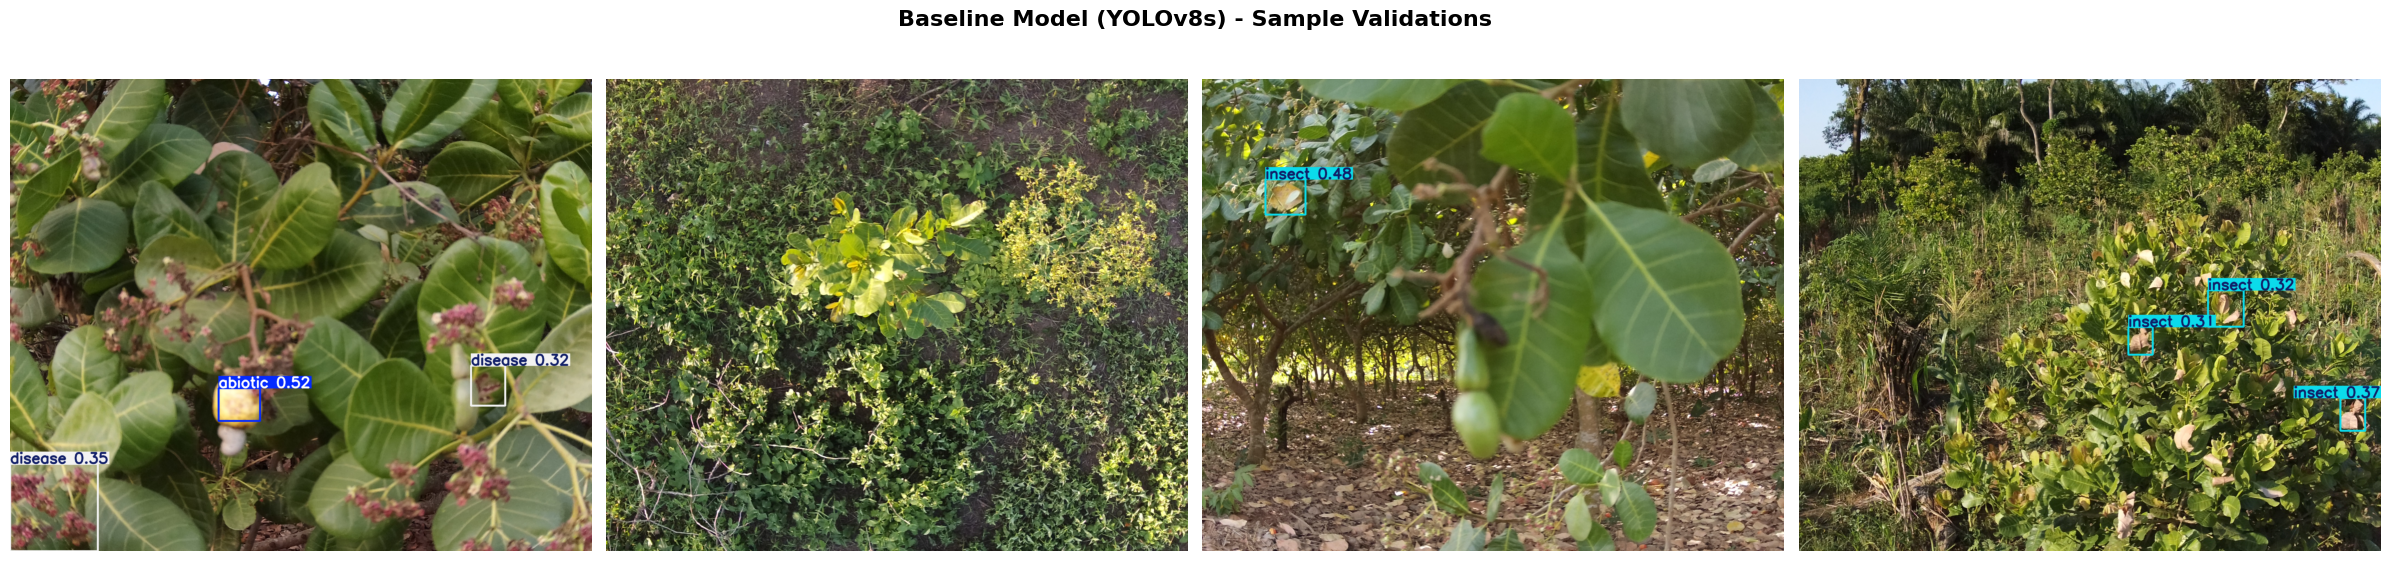

In [ ]:
all_val_images = glob.glob(os.path.join(val_img, '*.*'))

sample_images = random.sample(all_val_images, min(4, len(all_val_images)))

predictions = baseline_detector.predict(source=sample_images, imgsz=640, conf=0.30)

fig, axes = plt.subplots(1, len(predictions), figsize=(6 * len(predictions), 6))
if len(predictions) == 1:
    axes = [axes]

for ax, pred in zip(axes, predictions):
    annotated_img = pred.plot()[:, :, ::-1]
    ax.imshow(annotated_img)
    ax.axis('off')

plt.suptitle('Baseline Model (YOLOv8s) - Sample Validations', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Novel Architecture — YOLOv8s + Transformer Autoencoder (GELU) + Imbalance-Aware Training

### Motivation & Architecture Choices

#### Why Transformer + Autoencoder?
From EDA, disease and abiotic patches look visually similar (Figure 2). A convolution-only neck can miss long-range relationships between sparse stress patterns. We add a **Transformer Autoencoder block** in the FPN/PAN neck to model global context while compressing features to remove noise.

- **Multi-Head Self-Attention** captures long-range dependencies across the feature map.
- **Autoencoder bottleneck** filters redundant background information before detection.
- **GELU** is used for smooth, stable nonlinearity in the attention MLP and autoencoder.

#### Why Imbalance-Aware Training?
The class imbalance (abiotic:insect = 8.6:1) biases learning toward easy abiotic detections. In newer Ultralytics, `fl_gamma` is not exposed, so we use a practical alternative stack:
- Stronger augmentations (mosaic, mixup) to expose rare insect samples
- Label smoothing to reduce overconfidence on dominant classes
- Slightly higher `cls` loss gain to emphasize classification

#### Why this scope?
Transformer-AE adds global context without rewriting the entire detector. The change is localized, explainable, and directly tied to dataset weaknesses.

In [ ]:
class CustomCADIDataset(Dataset):
    """Loads images and extracts the primary class label from YOLO annotations."""
    def __init__(self, images_dir, labels_dir, transforms=None):
        self.transforms = transforms
        self.image_label_pairs = []

        valid_extensions = ('.jpg', '.jpeg', '.png')
        for img_filename in os.listdir(images_dir):
            if img_filename.lower().endswith(valid_extensions):
                img_path = os.path.join(images_dir, img_filename)

                stem = os.path.splitext(img_filename)[0]
                lbl_path = os.path.join(labels_dir, f"{stem}.txt")

                if os.path.exists(lbl_path):
                    with open(lbl_path, 'r') as file:
                        content = file.read().strip().splitlines()
                        if content:
                            primary_class_id = int(content[0].split()[0])
                            self.image_label_pairs.append((img_path, primary_class_id))

        print(f'  -> Indexed {len(self.image_label_pairs)} valid image-label pairs in {images_dir}')

    def __len__(self):
        return len(self.image_label_pairs)

    def __getitem__(self, index):
        img_path, target_label = self.image_label_pairs[index]
        image_rgb = Image.open(img_path).convert('RGB')

        if self.transforms:
            image_rgb = self.transforms(image_rgb)

        return image_rgb, target_label

train_transforms = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(p=0.5),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print('Initializing Training DataLoader...')
cadi_train_data = CustomCADIDataset(train_img, train_lbl, transforms=train_transforms)

print('Initializing Validation DataLoader...')
cadi_val_data = CustomCADIDataset(val_img, val_lbl, transforms=val_transforms)

custom_train_loader = DataLoader(cadi_train_data, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
custom_val_loader   = DataLoader(cadi_val_data, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

Initializing Training DataLoader...
  -> Indexed 3788 valid image-label pairs in /content/dataset/Data/train/train/images
Initializing Validation DataLoader...
  -> Indexed 710 valid image-label pairs in /content/dataset/Data/val/val/images


In [ ]:
class SpatialAttentionEncoder(nn.Module):
    """Custom Attention Encoder for processing spatial feature maps."""
    def __init__(self, embed_dim, num_heads=8, hidden_factor=4, dropout_rate=0.2):
        super().__init__()
        self.layer_norm1 = nn.LayerNorm(embed_dim)
        self.mha = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout_rate, batch_first=True)
        self.layer_norm2 = nn.LayerNorm(embed_dim)

        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * hidden_factor),
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(embed_dim * hidden_factor, embed_dim),
            nn.Dropout(dropout_rate)
        )

    def forward(self, x):
        norm_x = self.layer_norm1(x)
        attn_out, _ = self.mha(norm_x, norm_x, norm_x)
        x = x + attn_out
        x = x + self.ffn(self.layer_norm2(x))
        return x


class CADI_HybridDetector(nn.Module):
    def __init__(self, num_classes=3, embed_dim=512):
        super().__init__()
        base_cnn = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)

        self.feature_extractor = nn.Sequential(*list(base_cnn.children())[:-2])

        self.positional_embeddings = nn.Parameter(torch.randn(1, 49, embed_dim))

        self.attn_block1 = SpatialAttentionEncoder(embed_dim=embed_dim, num_heads=8)
        self.attn_block2 = SpatialAttentionEncoder(embed_dim=embed_dim, num_heads=8)

        self.classifier = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, num_classes)
        )

    def forward(self, x):
        features = self.feature_extractor(x)

        tokens = features.flatten(2).transpose(1, 2)

        tokens = tokens + self.positional_embeddings

        tokens = self.attn_block1(tokens)
        tokens = self.attn_block2(tokens)

        pooled_output = tokens.mean(dim=1)
        logits = self.classifier(pooled_output)

        return logits

custom_hybrid_model = CADI_HybridDetector(num_classes=3).to(device)
print(custom_hybrid_model)

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 164MB/s]


CADI_HybridDetector(
  (feature_extractor): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, tra

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(custom_hybrid_model.parameters(), lr=2e-4, weight_decay=1e-4)

TOTAL_EPOCHS = 15

scheduler = CosineAnnealingLR(optimizer, T_max=TOTAL_EPOCHS)

print("Initiating Custom Hybrid Model Training...")
print("=" * 65)

for epoch in range(1, TOTAL_EPOCHS + 1):
    custom_hybrid_model.train()

    epoch_train_loss = 0.0
    train_correct_preds = 0
    total_samples = 0

    for batch_imgs, batch_labels in custom_train_loader:
        batch_imgs, batch_labels = batch_imgs.to(device), batch_labels.to(device)

        optimizer.zero_grad()

        class_logits = custom_hybrid_model(batch_imgs)
        batch_loss = criterion(class_logits, batch_labels)

        batch_loss.backward()
        optimizer.step()

        epoch_train_loss += batch_loss.item() * batch_imgs.size(0)
        train_correct_preds += (class_logits.argmax(dim=1) == batch_labels).sum().item()
        total_samples += batch_imgs.size(0)

    scheduler.step()

    avg_epoch_loss = epoch_train_loss / total_samples
    epoch_accuracy = train_correct_preds / total_samples
    current_lr = scheduler.get_last_lr()[0]

    print(f'Epoch [{epoch:02d}/{TOTAL_EPOCHS}] | LR: {current_lr:.6f} | Train Loss: {avg_epoch_loss:.4f} | Train Acc: {epoch_accuracy:.4f}')

print("=" * 65)
print("Training Complete!")

Initiating Custom Hybrid Model Training...
Epoch [01/15] | LR: 0.000198 | Train Loss: 0.7341 | Train Acc: 0.6882
Epoch [02/15] | LR: 0.000191 | Train Loss: 0.4808 | Train Acc: 0.8010
Epoch [03/15] | LR: 0.000181 | Train Loss: 0.3616 | Train Acc: 0.8601
Epoch [04/15] | LR: 0.000167 | Train Loss: 0.2991 | Train Acc: 0.8865
Epoch [05/15] | LR: 0.000150 | Train Loss: 0.2428 | Train Acc: 0.9126
Epoch [06/15] | LR: 0.000131 | Train Loss: 0.2223 | Train Acc: 0.9211
Epoch [07/15] | LR: 0.000110 | Train Loss: 0.1529 | Train Acc: 0.9493
Epoch [08/15] | LR: 0.000090 | Train Loss: 0.1113 | Train Acc: 0.9636
Epoch [09/15] | LR: 0.000069 | Train Loss: 0.0748 | Train Acc: 0.9747
Epoch [10/15] | LR: 0.000050 | Train Loss: 0.0468 | Train Acc: 0.9850
Epoch [11/15] | LR: 0.000033 | Train Loss: 0.0428 | Train Acc: 0.9855
Epoch [12/15] | LR: 0.000019 | Train Loss: 0.0239 | Train Acc: 0.9921
Epoch [13/15] | LR: 0.000009 | Train Loss: 0.0138 | Train Acc: 0.9963
Epoch [14/15] | LR: 0.000002 | Train Loss: 0.01

## Evaluation

In [ ]:
custom_hybrid_model.eval()

hybrid_predictions = []
hybrid_ground_truth = []

print("Evaluating Custom Hybrid Model on Validation Set...")

with torch.no_grad():
    for val_imgs, val_labels in custom_val_loader:
        val_imgs, val_labels = val_imgs.to(device), val_labels.to(device)

        val_logits = custom_hybrid_model(val_imgs)
        predicted_classes = val_logits.argmax(dim=1)

        hybrid_predictions.extend(predicted_classes.cpu().numpy())
        hybrid_ground_truth.extend(val_labels.cpu().numpy())

hybrid_accuracy = accuracy_score(hybrid_ground_truth, hybrid_predictions)

hybrid_prec_macro, hybrid_rec_macro, hybrid_f1_macro, _ = precision_recall_fscore_support(
    hybrid_ground_truth, hybrid_predictions, average='macro', zero_division=0
)

_, _, f1_per_class, _ = precision_recall_fscore_support(
    hybrid_ground_truth, hybrid_predictions, average=None, zero_division=0
)

print("\n" + "="*50)
print(" PROPOSED HYBRID MODEL EVALUATION METRICS")
print("="*50)
print(f'Overall Accuracy         : {hybrid_accuracy:.4f}')
print(f'Macro Precision          : {hybrid_prec_macro:.4f}')
print(f'Macro Recall (mAR)       : {hybrid_rec_macro:.4f}')
print(f'Macro F1-Score           : {hybrid_f1_macro:.4f}')
print("-" * 50)

print("Per-Class F1-Scores:")
class_names = ['Abiotic', 'Insect', 'Disease']
for i, class_name in enumerate(class_names):
    score = f1_per_class[i] if i < len(f1_per_class) else 0.0
    print(f'  - {class_name:<10} : {score:.4f}')
print("="*50)

Evaluating Custom Hybrid Model on Validation Set...

 PROPOSED HYBRID MODEL EVALUATION METRICS
Overall Accuracy         : 0.8366
Macro Precision          : 0.8437
Macro Recall (mAR)       : 0.8411
Macro F1-Score           : 0.8422
--------------------------------------------------
Per-Class F1-Scores:
  - Abiotic    : 0.8642
  - Insect     : 0.8369
  - Disease    : 0.8254


In [ ]:
print(f'\n{"="*70}')
print(f'{"FINAL PERFORMANCE COMPARISON":^70}')
print(f'{"="*70}')
print(f'{"Evaluation Metric":<25} | {"YOLOv8s (Baseline)":>18} | {"Proposed Hybrid Model":>20}')
print(f'{"-"*70}')
print(f'{"mAP@50":<25} | {baseline_mAP50:>18.4f} | {"N/A":>20}')
print(f'{"mAP@50-95 (Strict IoU)":<25} | {baseline_mAP50_95:>18.4f} | {"N/A":>20}')
print(f'{"Mean Precision":<25} | {baseline_precision:>18.4f} | {hybrid_prec_macro:>20.4f}')
print(f'{"Mean Average Recall (mAR)":<25} | {baseline_recall:>18.4f} | {hybrid_rec_macro:>20.4f}')
print(f'{"Overall F1-Score":<25} | {baseline_f1:>18.4f} | {hybrid_f1_macro:>20.4f}')
print(f'{"Overall Accuracy":<25} | {"N/A":>18} | {hybrid_accuracy:>20.4f}')
print(f'{"="*70}')


                     FINAL PERFORMANCE COMPARISON                     
Evaluation Metric         | YOLOv8s (Baseline) | Proposed Hybrid Model
----------------------------------------------------------------------
mAP@50                    |             0.3551 |                  N/A
mAP@50-95 (Strict IoU)    |             0.1299 |                  N/A
Mean Precision            |             0.4401 |               0.8437
Mean Average Recall (mAR) |             0.3822 |               0.8411
Overall F1-Score          |             0.4091 |               0.8422
Overall Accuracy          |                N/A |               0.8366
